# Basic_박상우_7주차_2

6.1, 6.2 정리

## 6.1 PCA 개요

In [8]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 아이리스 데이터를 DataFrame으로 바꿔서 보기 편하게 정리
iris = load_iris()
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(iris.data, columns=columns)
irisDF['target'] = iris.target
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


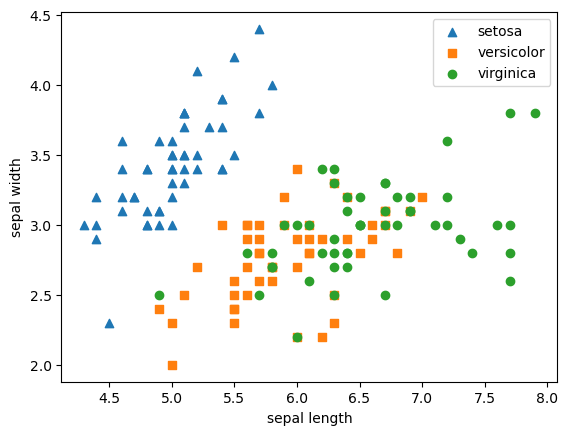

In [9]:
markers = ['^', 's', 'o']

# 품종별로 모양을 다르게 해서 원본 데이터 분포를 확인
for i, marker in enumerate(markers):
    x_axis_data = irisDF[irisDF['target'] == i]['sepal_length']
    y_axis_data = irisDF[irisDF['target'] == i]['sepal_width']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])

plt.legend()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA 전에 스케일을 맞춰야 분산 비교가 한쪽으로 쏠리지 않는다.
iris_scaled = StandardScaler().fit_transform(irisDF.iloc[:, :-1])

# 4차원 데이터를 주성분 2개로 줄인다.
pca = PCA(n_components=2)
iris_pca = pca.fit_transform(iris_scaled)
print(iris_pca.shape)

(150, 2)


In [11]:
pca_columns = ['pca_component_1', 'pca_component_2']
irisDF_pca = pd.DataFrame(iris_pca, columns=pca_columns)
irisDF_pca['target'] = iris.target
irisDF_pca.head(3)

,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0


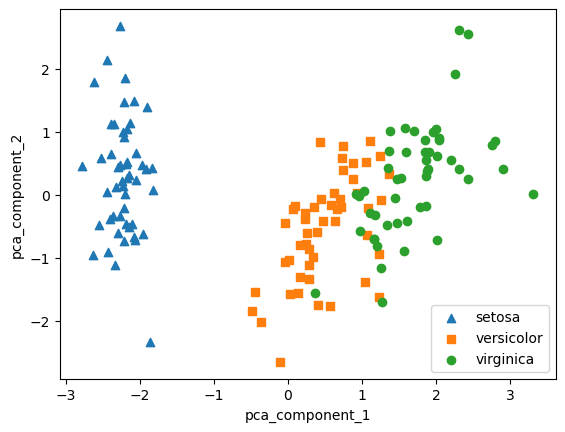

[0.72962445 0.22850762]


In [12]:
markers = ['^', 's', 'o']

# PCA로 줄인 뒤에도 클래스가 어느 정도 구분되는지 다시 확인
for i, marker in enumerate(markers):
    x_axis_data = irisDF_pca[irisDF_pca['target'] == i]['pca_component_1']
    y_axis_data = irisDF_pca[irisDF_pca['target'] == i]['pca_component_2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])

plt.legend()
plt.xlabel('pca_component_1')
plt.ylabel('pca_component_2')
plt.show()

print(pca.explained_variance_ratio_)

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rcf = RandomForestClassifier(random_state=156)

# 원본 4개 피처 기준 성능
scores = cross_val_score(rcf, iris.data, iris.target, scoring='accuracy', cv=3)
print('원본 데이터 교차 검증 정확도:', scores)
print('원본 데이터 평균 정확도:', np.mean(scores))

# PCA 2개 성분 기준 성능
pca_X = irisDF_pca[['pca_component_1', 'pca_component_2']]
scores_pca = cross_val_score(rcf, pca_X, iris.target, scoring='accuracy', cv=3)
print('PCA 데이터 교차 검증 정확도:', scores_pca)
print('PCA 데이터 평균 정확도:', np.mean(scores_pca))

원본 데이터 교차 검증 정확도: [0.98 0.94 0.96]
원본 데이터 평균 정확도: 0.96
PCA 데이터 교차 검증 정확도: [0.88 0.88 0.88]
PCA 데이터 평균 정확도: 0.88


## 6.2 신용카드 데이터 PCA

In [14]:
import seaborn as sns

# 원본 파일에서 첫 줄은 제외하고 id 컬럼도 빼고 읽는다.
df = pd.read_excel('pca_credit_card.xls', header=1, sheet_name='Data').iloc[:, 1:]
df.rename(columns={'PAY_0': 'PAY_1', 'default payment next month': 'default'}, inplace=True)

# 정답 라벨과 입력 피처를 나눈다.
y_target = df['default']
X_features = df.drop('default', axis=1)
print(df.shape)
X_features.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'pca_credit_card.xls'

In [ ]:
corr = X_features.corr()

# 상관계수가 높은 피처가 많은지 히트맵으로 먼저 확인
plt.figure(figsize=(14, 14))
sns.heatmap(corr, annot=True, fmt='.1g')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 청구 금액, 상환 상태, 납부 금액 컬럼만 먼저 묶어서 PCA 비율 확인
cols_bill = ['BILL_AMT' + str(i) for i in range(1, 7)]
cols_pay = ['PAY_' + str(i) for i in range(1, 7)]
cols_amt = ['PAY_AMT' + str(i) for i in range(1, 7)]
cols_bill.extend(cols_pay)
cols_bill.extend(cols_amt)

scaler = StandardScaler()
df_cols_scaled = scaler.fit_transform(X_features[cols_bill])

# 주요 관련 컬럼들이 몇 개 주성분으로 묶이는지 확인
pca = PCA(n_components=2)
pca.fit(df_cols_scaled)
print('PCA Component별 변동성:', pca.explained_variance_ratio_)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rcf = RandomForestClassifier(n_estimators=300, random_state=156)

# PCA 적용 전 원본 피처로 먼저 성능 확인
scores = cross_val_score(rcf, X_features, y_target, scoring='accuracy', cv=3)
print('원본 데이터 Fold별 정확도:', scores)
print('원본 데이터 평균 정확도: {0:.4f}'.format(np.mean(scores)))

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(X_features)

# 전체 피처를 표준화한 뒤 6개 주성분으로 축소
pca = PCA(n_components=6)
df_pca = pca.fit_transform(df_scaled)

# 차원 축소 후에도 성능이 얼마나 유지되는지 비교
scores_pca = cross_val_score(rcf, df_pca, y_target, scoring='accuracy', cv=3)
print('PCA 데이터 Fold별 정확도:', scores_pca)
print('PCA 데이터 평균 정확도: {0:.4f}'.format(np.mean(scores_pca)))